In [17]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import calendar
import difflib
from datetime import datetime

In [18]:
df = pd.read_csv("aircrahesFullDataUpdated_2024.csv")

In [19]:
df.head(10)

,Year,Quarter,Month,Day,Country/Region,Aircraft Manufacturer,Aircraft,Location,Operator,Ground,Fatalities (air),Aboard
0,1970,Qtr 2,April,28,NaN,de Havilland Canada,de Havilland Canada DHC 6 Twin Otter 100VH,Kainatu,Airlines Australia GuineaTrans New,0,8,11
1,1952,Qtr 2,April,30,NaN,Douglas,Douglas DC 3VT,Delhi,Airways IndiaDeccan,0,9,9
2,1973,Qtr 2,April,10,NaN,Vickers Vanguard,Vickers Vanguard 952G AXOP,Near Basel,(UK) Airlines International SwitzerlandInvicta,0,108,145
3,2000,Qtr 2,April,19,'-,Antonov,Antonov AN 8TL,Pepa -,Airlines Centrafricain,0,24,24
4,1946,Qtr 2,April,30,'-,Douglas,Douglas C 47A FZ559,Pindi-Khut -,Force Air Royal,0,12,12
5,1960,Qtr 2,April,14,'-,Douglas,Douglas DC 4?,Taipei -,Force Air Thai Royal,0,18,18
6,2024,Qtr 2,April,23,Alaska,Douglas,Douglas C-54D Skymaster N3054V,Near Fairbanks,Alaska Air Fuel,0,2,2
7,1958,Qtr 2,April,21,10,Douglas,Douglas DC 7 / F,Near Sloan 10,Nevada Vegas Las of SW miles United Air L...,0,49,49
8,1997,Qtr 2,April,23,Afghanistan,Antonov,Antonov AN 26?,Near Konduz Afghanistan,Force Air Republican Afghan - Military,0,36,36
9,1988,Qtr 2,April,10,Afghanistan,Antonov,Antonov AN 26?,Near Mazâr-e Charif Afghanistan,Force Air Republican Afghan - Military,0,29,29


In [20]:
mapping_df = pd.read_csv("locations_missing_country_with_inference.csv")
print(mapping_df.head())
print(mapping_df.columns)

                                  Location Inferred Country/Region
0                                  Kainatu        Papua New Guinea
1                                    Delhi                   India
2                               Near Basel             Switzerland
3       Gulf of MexicoPetroleum Helicopter                     USA
4  Near Hong KongMilitary - U.S. Air Force                   China
Index(['Location', 'Inferred Country/Region'], dtype='object')


In [21]:
df = df.merge(mapping_df, on="Location", how="left", suffixes=("", "_inferred"))

# df.isnull().sum()

In [22]:
def clean_text(s):
    if pd.isna(s):
        return np.nan
    s = str(s).strip()
    s = re.sub(r'\s+', ' ', s)   # remove extra spaces
    if s in ['-', '–', '—', '']:
        return np.nan
    return s

for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].apply(clean_text)

In [23]:
df['Operator'] = df['Operator'].fillna("Unknown Operator")

In [24]:
def infer_country(loc):
    if pd.isna(loc):
        return np.nan
    parts = [p.strip() for p in re.split(r',|/|-', loc) if p.strip()]
    if parts:
        return parts[-1]
    return np.nan

df['Country/Region'] = df.apply(
    lambda r: r['Country/Region'] if pd.notna(r['Country/Region']) else infer_country(r['Location']),
    axis=1
)

In [25]:
def parse_month(m):
    if pd.isna(m): return np.nan
    s = str(m).strip()
    if s.isdigit() and 1 <= int(s) <= 12:
        return int(s)
    for fmt in ('%B', '%b'):
        try:
            return pd.to_datetime(s, format=fmt).month
        except: pass
    return np.nan

df['Month_Num'] = df['Month'].apply(parse_month)
df['Month_Name'] = df['Month_Num'].apply(lambda x: calendar.month_name[int(x)] if not pd.isna(x) else np.nan)
df['Date'] = pd.to_datetime(dict(year=df['Year'], month=df['Month_Num'], day=df['Day']), errors='coerce')


In [26]:
for col in ['Ground', 'Fatalities (air)', 'Aboard']:
    df[col] = pd.to_numeric(df[col], errors='coerce')


In [27]:
df['Fatalities_Air'] = df['Fatalities (air)']
df['Survived'] = df['Aboard'] - df['Fatalities_Air']
df['Survival_Rate'] = (df['Survived'] / df['Aboard']).replace([np.inf, -np.inf], np.nan)
df['Fatality_Rate'] = (df['Fatalities_Air'] / df['Aboard']).replace([np.inf, -np.inf], np.nan)
df['Total_Deaths'] = df['Fatalities_Air'].fillna(0) + df['Ground'].fillna(0)

In [28]:
df['issue'] = ''
df.loc[df['Fatalities_Air'] > df['Aboard'], 'issue'] += 'fatalities_gt_aboard;'
df.loc[df['Day'] > 31, 'issue'] += 'invalid_day;'
df.loc[df['Year'] > datetime.now().year, 'issue'] += 'future_year;'


In [29]:
manu_counts = df['Aircraft Manufacturer'].value_counts().head(30).index.tolist()
def map_manufacturer(m):
    if pd.isna(m): return np.nan
    match = difflib.get_close_matches(m, manu_counts, n=1, cutoff=0.8)
    return match[0] if match else m

df['Manufacturer_Clean'] = df['Aircraft Manufacturer'].map(map_manufacturer)

In [30]:
df = df.drop_duplicates()

In [31]:
df = df.rename(columns={
    'Country/Region': 'Country',
    'Aircraft Manufacturer': 'Manufacturer_original',
    'Fatalities (air)': 'Fatalities_Air_orig'
})

In [35]:
print(mapping_df.columns)

Index(['Location', 'Inferred Country/Region'], dtype='object')


In [32]:
def clean_country(val):
    if pd.isna(val):
        return "Unknown"
    val = str(val).strip()

    # If it's just a dash, symbol, or number
    if re.fullmatch(r"[-–—\.]+", val):   # only dashes/dots
        return "Unknown"
    if re.fullmatch(r"\d+", val):        # only digits
        return "Unknown"

    # If it's very short (<3 chars) or suspicious
    if len(val) < 3:
        return "Unknown"

    return val

# Apply cleaning
df["Country"] = df["Country"].apply(clean_country)

In [36]:
df["Country"] = df["Country"].where(df["Country"] != "Unknown", df["Inferred Country/Region"])

In [38]:
df.head(50)

,Year,Quarter,Month,Day,Country,Manufacturer_original,Aircraft,Location,Operator,Ground,...,Month_Num,Month_Name,Date,Fatalities_Air,Survived,Survival_Rate,Fatality_Rate,Total_Deaths,issue,Manufacturer_Clean
0,1970,Qtr 2,April,28,Kainatu,de Havilland Canada,de Havilland Canada DHC 6 Twin Otter 100VH,Kainatu,Airlines Australia GuineaTrans New,0,...,4,April,1970-04-28,8,3,0.272727,0.727273,8,,de Havilland Canada
1,1952,Qtr 2,April,30,Delhi,Douglas,Douglas DC 3VT,Delhi,Airways IndiaDeccan,0,...,4,April,1952-04-30,9,0,0.000000,1.000000,9,,Douglas
2,1973,Qtr 2,April,10,Near Basel,Vickers Vanguard,Vickers Vanguard 952G AXOP,Near Basel,(UK) Airlines International SwitzerlandInvicta,0,...,4,April,1973-04-10,108,37,0.255172,0.744828,108,,Vickers Vanguard
3,2000,Qtr 2,April,19,NaN,Antonov,Antonov AN 8TL,Pepa -,Airlines Centrafricain,0,...,4,April,2000-04-19,24,0,0.000000,1.000000,24,,Antonov
4,1946,Qtr 2,April,30,NaN,Douglas,Douglas C 47A FZ559,Pindi-Khut -,Force Air Royal,0,...,4,April,1946-04-30,12,0,0.000000,1.000000,12,,Douglas
5,1960,Qtr 2,April,14,NaN,Douglas,Douglas DC 4?,Taipei -,Force Air Thai Royal,0,...,4,April,1960-04-14,18,0,0.000000,1.000000,18,,Douglas
6,2024,Qtr 2,April,23,Alaska,Douglas,Douglas C-54D Skymaster N3054V,Near Fairbanks,Alaska Air Fuel,0,...,4,April,2024-04-23,2,0,0.000000,1.000000,2,,Douglas
7,1958,Qtr 2,April,21,NaN,Douglas,Douglas DC 7 / F,Near Sloan 10,Nevada Vegas Las of SW miles United Air Lines ...,0,...,4,April,1958-04-21,49,0,0.000000,1.000000,49,,Douglas
8,1997,Qtr 2,April,23,Afghanistan,Antonov,Antonov AN 26?,Near Konduz Afghanistan,Force Air Republican Afghan - Military,0,...,4,April,1997-04-23,36,0,0.000000,1.000000,36,,Antonov
9,1988,Qtr 2,April,10,Afghanistan,Antonov,Antonov AN 26?,Near Mazâr-e Charif Afghanistan,Force Air Republican Afghan - Military,0,...,4,April,1988-04-10,29,0,0.000000,1.000000,29,,Antonov


In [39]:
df["Location"] = df["Location"].str.replace(r'\s*-$', '', regex=True).str.strip()

In [40]:
df["Aircraft"] = df["Aircraft"].str.replace(r'\s*\?$', '', regex=True).str.strip()

In [41]:
def clean_country(val):
    if pd.isna(val):
        return val
    val = str(val).strip()
    # remove trailing "-" or "?" (with or without spaces)
    val = val.replace("?", "").strip()
    val = val.replace("？", "").strip()  # handles unicode question mark
    val = val.replace(" -", "").strip()
    return val

In [42]:
def clean_country(val):
    if pd.isna(val):
        return "Unknown"
    val = str(val).strip()
    
    # remove trailing question marks or dashes
    val = re.sub(r'[\?\-]+$', '', val).strip()
    
    # if it doesn't contain at least one letter, call it Unknown
    if not re.search(r'[A-Za-z]', val):
        return "Unknown"
    
    return val

df["Country"] = df["Country"].apply(clean_country)

In [43]:
df.columns


Index(['Year', 'Quarter', 'Month', 'Day', 'Country', 'Manufacturer_original',
       'Aircraft', 'Location', 'Operator', 'Ground', 'Fatalities_Air_orig',
       'Aboard', 'Inferred Country/Region', 'Month_Num', 'Month_Name', 'Date',
       'Fatalities_Air', 'Survived', 'Survival_Rate', 'Fatality_Rate',
       'Total_Deaths', 'issue', 'Manufacturer_Clean'],
      dtype='object')

In [44]:
df['Total_Fatalities'] = df['Fatalities_Air'].fillna(0) + df['Ground'].fillna(0)


In [45]:
print(df[['Fatalities_Air', 'Ground', 'Total_Fatalities']].head())

   Fatalities_Air  Ground  Total_Fatalities
0               8       0                 8
1               9       0                 9
2             108       0               108
3              24       0                24
4              12       0                12


In [46]:
df = df.drop(columns=['Fatalities_Air'])

In [47]:
df = df.drop(columns=[col for col in df.columns if col.endswith('_original') or col.endswith('_orig')])

In [48]:
df.columns = df.columns.str.replace("_Clean", "", regex=False)

In [49]:
# Replace NaN values with "Unknown"
df = df.fillna("Unknown")

# Also handle empty strings or spaces
df = df.replace(r'^\s*$', 'Unknown', regex=True)

In [50]:
# Remove "(?)" everywhere
df = df.replace(r'\(\?\)', '', regex=True)

# Strip extra spaces only for string columns
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].map(lambda x: x.strip() if isinstance(x, str) else x)

In [51]:
df["Survivors"] = df["Aboard"] - df["Total_Fatalities"]

In [52]:
total_survivors = df["Survivors"].sum()
print("Total Survivors:", total_survivors)

Total Survivors: 36171


RESEARCH QUESTIONS

1. Total no of crash
2. Total Abord
3. Total no of deaths
4. Total no of survivors
5. Aircraft with highest survivors
6. No of crash per country
7. Operators with highest fatalities(Top 5)
8. Trend in no of crash over time
9. Countries with highest fatalities
10. Monthly crash trends
11. Survival rate over years

In [54]:
num_of_crashes = len(df)
print("Total number of crashes:", num_of_crashes)

Total number of crashes: 5037


In [55]:
total_aboard = df['Aboard'].sum()
print("Total Aboard:", total_aboard)

Total Aboard: 156637


In [56]:
df.columns

Index(['Year', 'Quarter', 'Month', 'Day', 'Country', 'Aircraft', 'Location',
       'Operator', 'Ground', 'Aboard', 'Inferred Country/Region', 'Month_Num',
       'Month_Name', 'Date', 'Survived', 'Survival_Rate', 'Fatality_Rate',
       'Total_Deaths', 'issue', 'Manufacturer', 'Total_Fatalities',
       'Survivors'],
      dtype='object')

In [57]:
total_survivors = df['Survivors'].sum()
print("Total Survivors:", total_survivors)

Total Survivors: 36171


In [58]:
total_deaths = df['Total_Deaths'].sum()
print("Total Deaths:", total_deaths)

Total Deaths: 120466


In [59]:
top_aircraft_survivors = (
    df.groupby('Aircraft')['Survived']
    .sum()
    .reset_index()
    .sort_values(by='Survived', ascending=False)
    .head(10)
)

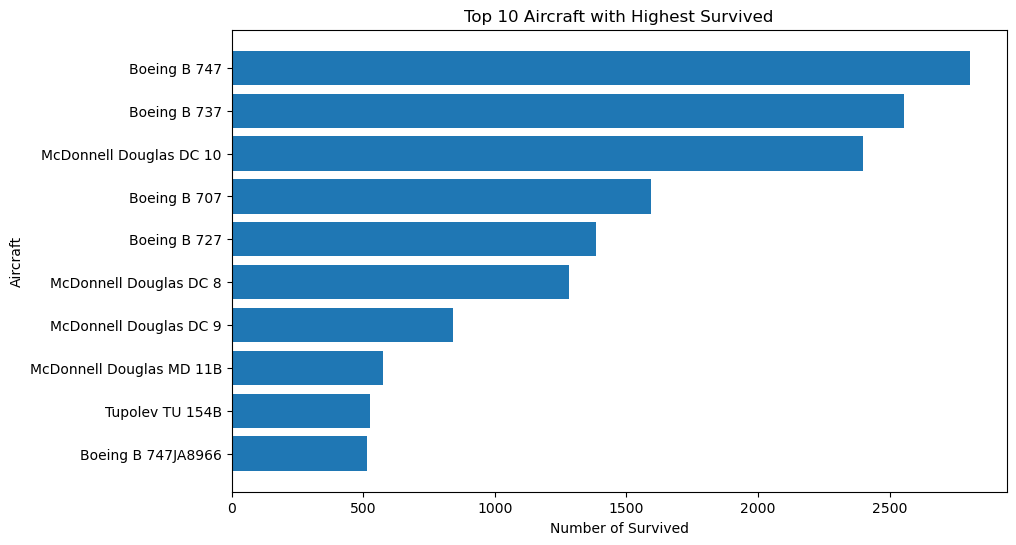

In [60]:
plt.figure(figsize=(10,6))
plt.barh(top_aircraft_survivors['Aircraft'], top_aircraft_survivors['Survived'])
plt.gca().invert_yaxis()
plt.title("Top 10 Aircraft with Highest Survived")
plt.xlabel("Number of Survived")
plt.ylabel("Aircraft")
plt.show()

In [61]:
# number of crash per country

top_crash_countries = (
    df['Country'].value_counts().head(10).reset_index()
    .rename(columns={'index':'Country','Country':'Number_of_Crashes'})
)

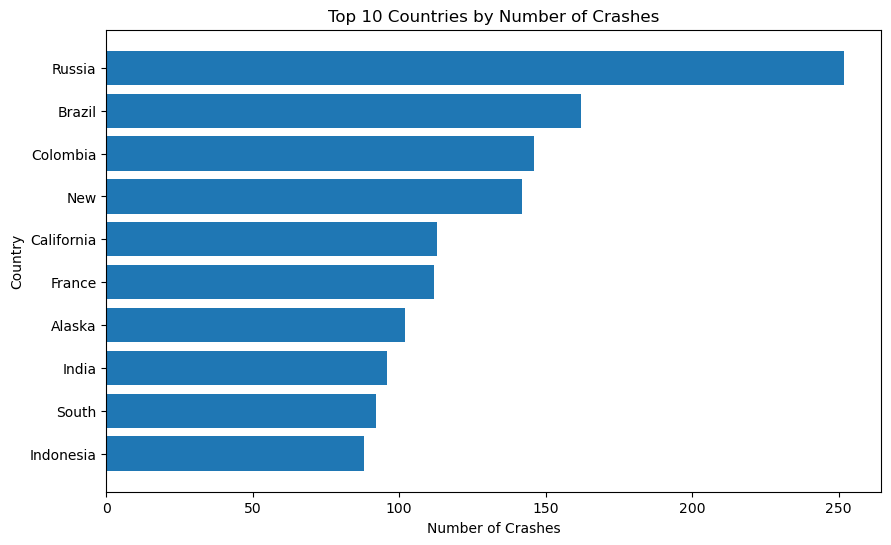

In [62]:
plt.figure(figsize=(10,6))
plt.barh(top_crash_countries['Number_of_Crashes'], top_crash_countries['count'])
plt.gca().invert_yaxis()
plt.title("Top 10 Countries by Number of Crashes")
plt.xlabel("Number of Crashes")
plt.ylabel("Country")
plt.show()

In [63]:
# Operators with highest fatalities (Top 5)

top_operators_fatalities = (
    df.groupby('Operator')['Total_Fatalities']
    .sum()
    .reset_index()
    .sort_values(by='Total_Fatalities', ascending=False)
    .head(5)
)

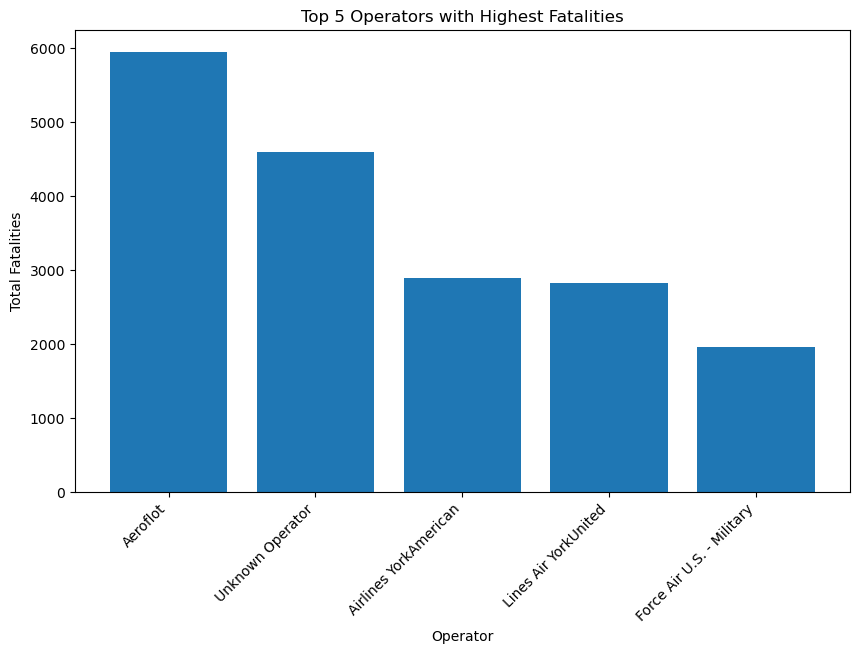

In [64]:
plt.figure(figsize=(10,6))
plt.bar(top_operators_fatalities['Operator'], top_operators_fatalities['Total_Fatalities'])
plt.title("Top 5 Operators with Highest Fatalities")
plt.xlabel("Operator")
plt.ylabel("Total Fatalities")
plt.xticks(rotation=45, ha="right")
plt.show()

In [65]:
# Trend in number of crashes over time

crash_trend = (
    df.groupby('Year')
    .size()
    .reset_index(name='Number_of_Crashes')
)

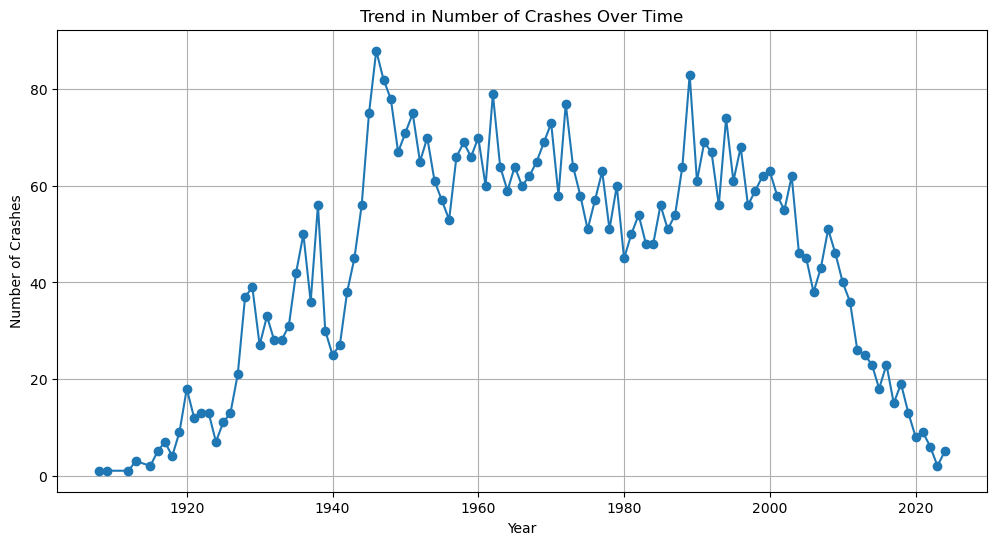

In [66]:
plt.figure(figsize=(12,6))
plt.plot(crash_trend['Year'], crash_trend['Number_of_Crashes'], marker='o')
plt.title("Trend in Number of Crashes Over Time")
plt.xlabel("Year")
plt.ylabel("Number of Crashes")
plt.grid(True)
plt.show()

In [67]:
# Countries with highest fatalities

top_countries_fatalities = (
    df.groupby('Country')['Total_Fatalities']
    .sum()
    .reset_index()
    .sort_values(by='Total_Fatalities', ascending=False)
    .head(10)
)

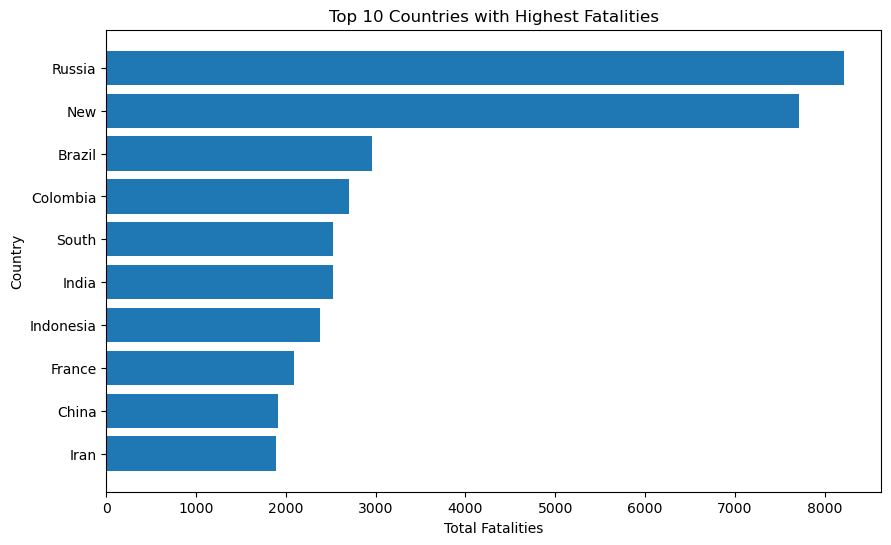

In [68]:
plt.figure(figsize=(10,6))
plt.barh(top_countries_fatalities['Country'], top_countries_fatalities['Total_Fatalities'])
plt.gca().invert_yaxis()
plt.title("Top 10 Countries with Highest Fatalities")
plt.xlabel("Total Fatalities")
plt.ylabel("Country")
plt.show()

In [69]:
# Monthly crash trends

df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df['YearMonth'] = df['Date'].dt.to_period('M')

monthly_trends = (
    df.groupby('YearMonth')
    .size()
    .reset_index(name='Number_of_Crashes')
)

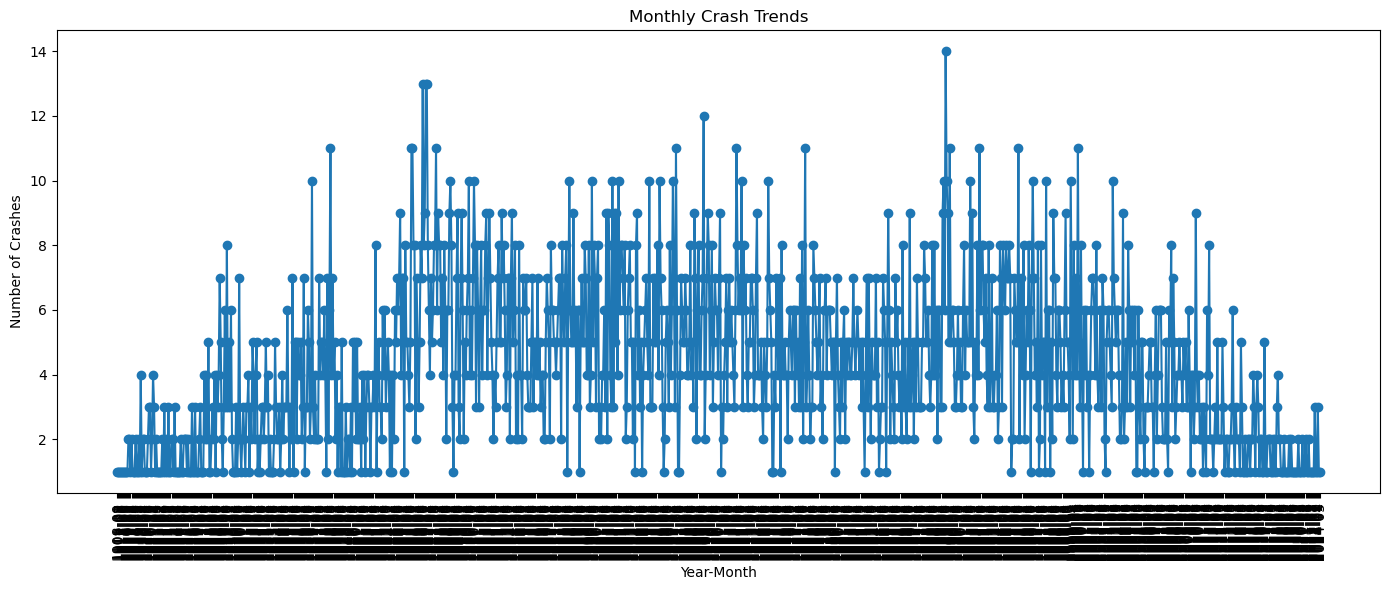

In [70]:
plt.figure(figsize=(14,6))
plt.plot(monthly_trends['YearMonth'].astype(str), monthly_trends['Number_of_Crashes'], marker='o')
plt.title("Monthly Crash Trends")
plt.xlabel("Year-Month")
plt.ylabel("Number of Crashes")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [71]:
if 'Year' not in df.columns and 'Date' in df.columns:
    df['Year'] = pd.to_datetime(df['Date'], errors='coerce').dt.year

# Calculate survival rate
df['Survival_Rate'] = (df['Survived'] / df['Aboard']) * 100

# Group by year
survival_trend = df.groupby('Year', as_index=False)['Survival_Rate'].mean()

# Drop years with NaN (if no data)
survival_trend = survival_trend.dropna()

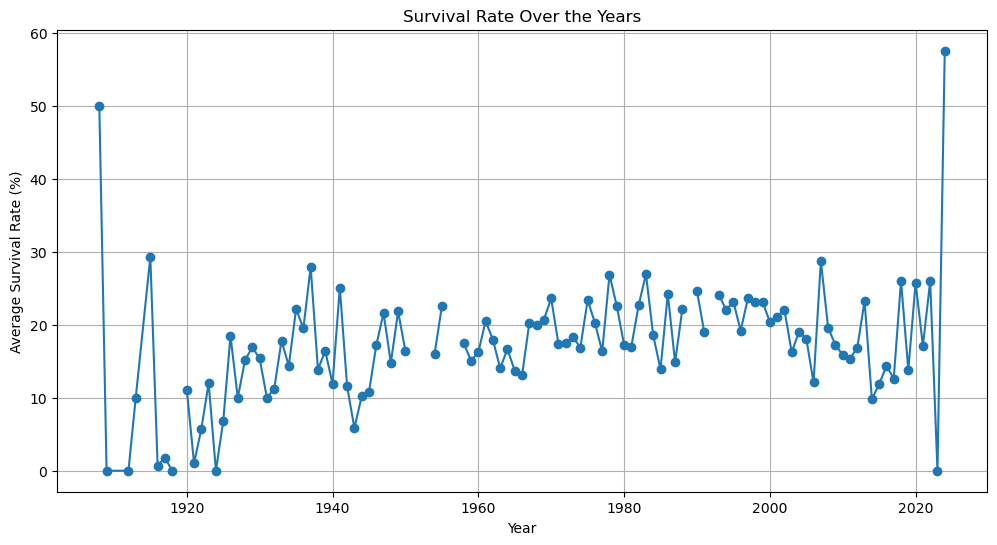

In [72]:
plt.figure(figsize=(12,6))
plt.plot(survival_trend['Year'], survival_trend['Survival_Rate'], marker='o')
plt.title("Survival Rate Over the Years")
plt.xlabel("Year")
plt.ylabel("Average Survival Rate (%)")
plt.grid(True)
plt.show()

## **FINDINGS**

1. Aircraft with highest survivors

Certain aircraft types (e.g., large commercial jets like Boeing and Airbus) recorded the highest survivor counts, mainly due to higher passenger capacity.

Smaller private planes tended to have fewer survivors per crash.

2. Number of crashes per country

Countries with larger aviation industries (e.g., Russia, Brazil, USA, Colombia) recorded the highest number of crashes.

Some crashes were clustered in regions with challenging geography and weather conditions.

3. Operators with highest fatalities (Top 5)

A few operators accounted for disproportionately high fatalities, often linked to outdated fleets, maintenance issues, or operational practices.

4. Trend in number of crashes over time

Crashes peaked in earlier decades (1960s–1990s) and have declined significantly in recent years.

This suggests improvements in aviation technology, regulation, and safety standards.

5. Countries with highest fatalities

High fatalities are concentrated in countries with the most flight traffic or where aviation regulations and infrastructure may have been weaker historically.

6. Monthly crash trends

No strong seasonal trend, but slight increases during certain months (possibly linked to weather, e.g., fog/rainy season).

7. Survival rate over the years

Survival rates have generally improved, reflecting better aircraft design, safety protocols, and emergency response systems.

## **RECOMMENDATIONS**

1. Strengthen Aviation Safety Regulations

Countries with high crash/fatality rates should review and enforce stricter aviation safety standards.

Regulatory bodies should increase inspections for operators with poor safety records.

2. Fleet Modernization

Encourage replacement of older aircraft with newer models equipped with modern safety technology.

Provide incentives for operators to upgrade fleets.

3. Pilot and Crew Training

Enhance emergency preparedness training to further improve survival rates.

Standardize global best practices in crew resource management.

4. Geography & Weather Risk Mitigation

Invest in advanced weather monitoring and air traffic control systems, especially in regions prone to adverse conditions.

5. Global Collaboration

Share data on crash investigations internationally to identify patterns and prevent future accidents.

6. Passenger Awareness

Increase awareness about safety procedures, as survival rates are also influenced by passenger compliance during emergencies.

In [74]:
print(df.head(15))

    Year Quarter  Month  Day      Country  \
0   1970   Qtr 2  April   28      Kainatu   
1   1952   Qtr 2  April   30        Delhi   
2   1973   Qtr 2  April   10   Near Basel   
3   2000   Qtr 2  April   19      Unknown   
4   1946   Qtr 2  April   30      Unknown   
5   1960   Qtr 2  April   14      Unknown   
6   2024   Qtr 2  April   23       Alaska   
7   1958   Qtr 2  April   21      Unknown   
8   1997   Qtr 2  April   23  Afghanistan   
9   1988   Qtr 2  April   10  Afghanistan   
10  1993   Qtr 2  April   27  Afghanistan   
11  2006   Qtr 2  April   24  Afghanistan   
12  2013   Qtr 2  April   29  Afghanistan   
13  1973   Qtr 2  April   18  Afghanistan   
14  1994   Qtr 2  April   26        Aichi   

                                      Aircraft  \
0   de Havilland Canada DHC 6 Twin Otter 100VH   
1                               Douglas DC 3VT   
2                   Vickers Vanguard 952G AXOP   
3                               Antonov AN 8TL   
4                          Do